In [ ]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 36.8841,
    "longitude": 30.7056,
    "start_date": "2015-01-01",
    "end_date":   "2024-12-31",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
    "timezone": "Europe/Istanbul"
}

resp = requests.get(url, params=params)
df   = pd.DataFrame(resp.json()["daily"])
df.to_csv("antalya_hava.csv", index=False)
print(df.head())

         time  temperature_2m_max  temperature_2m_min  precipitation_sum
0  2015-01-01                11.8                 8.2               15.3
1  2015-01-02                13.9                 6.5                0.0
2  2015-01-03                14.3                 3.9                0.2
3  2015-01-04                12.7                 5.6                0.3
4  2015-01-05                15.3                 8.4               10.8


In [4]:
# Tarih sütununu düzgün formata çevir
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)

# Eksik değer kontrolü
print("Eksik değerler:")
print(df.isnull().sum())

# Temel istatistikler
print("\nGenel istatistikler:")
print(df.describe().round(1))

Eksik değerler:
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
dtype: int64

Genel istatistikler:
       temperature_2m_max  temperature_2m_min  precipitation_sum
count              3653.0              3653.0             3653.0
mean                 24.8                14.5                2.7
std                   8.3                 6.9                8.9
min                   1.8                -2.3                0.0
25%                  17.8                 8.8                0.0
50%                  24.5                13.7                0.0
75%                  31.6                20.6                0.5
max                  44.6                31.4              124.5


In [5]:
# Yıl ve Ay sütunları ekle
df['yil'] = df.index.year
df['ay'] = df.index.month

# Mevsimleri tanımla
def mevsim_getir(ay):
    if ay in [12, 1, 2]: return 'Kış'
    elif ay in [3, 4, 5]: return 'İlkbahar'
    elif ay in [6, 7, 8]: return 'Yaz'
    else: return 'Sonbahar'

df['mevsim'] = df['ay'].apply(mevsim_getir)

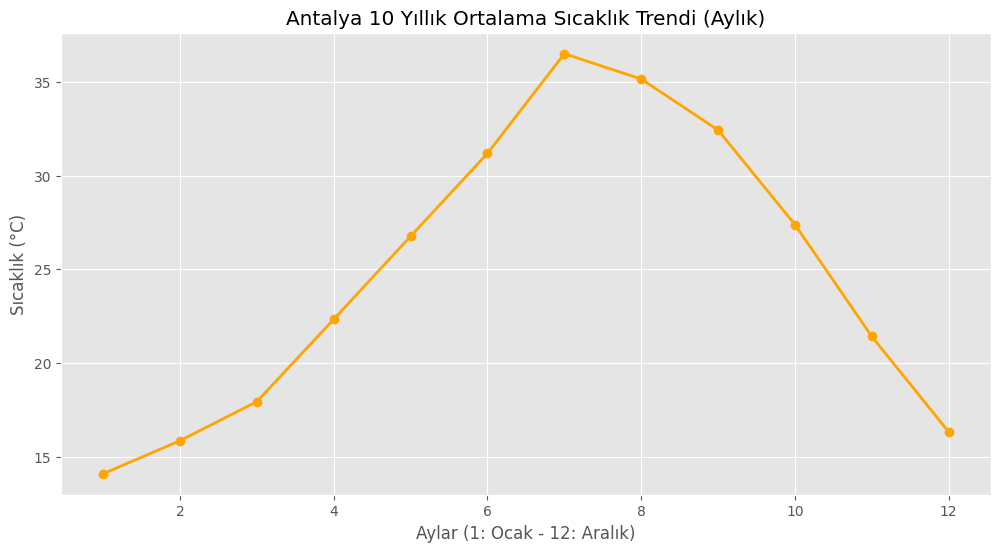

In [6]:
import matplotlib.pyplot as plt

# Grafik stilini ayarla
plt.style.use('ggplot')
plt.figure(figsize=(12, 6))

# Aylık ortalama maksimum sıcaklıkları çizdir
aylik_ort = df.groupby('ay')['temperature_2m_max'].mean()
aylik_ort.plot(kind='line', marker='o', color='orange', linewidth=2)

plt.title('Antalya 10 Yıllık Ortalama Sıcaklık Trendi (Aylık)')
plt.xlabel('Aylar (1: Ocak - 12: Aralık)')
plt.ylabel('Sıcaklık (°C)')
plt.grid(True)
plt.show()

In [ ]:
# çizgi grafiği yorumlaması :
'''
Zirve ve Dip Noktalari:

Antalya'da sicaklik Temmuz (7. ay) ayinda pik yapiyor (37°C ortalama maks)
En düşük seviye ise Ocak ayinda (14°C)


Isinma ve Soğuma Hizi:
Mart ile Haziran arasindaki dik eğim, ilkbaharin 
çok hizli geçtiğini ve yaz sicaklarinin aniden bastirdigini gösteriyor.
Eylül-Ekim arasindaki düşüş biraz daha yumuşak bir geçiş vardir

Süreklilik: 
Grafik mükemmel bir "çan eğrisi" (ters U) formunda. Bu,verinin mevsimsellik 
etkisinin çok baskin olduğunu ve periyodik bir yapida olduğunu kanitlar.
'''

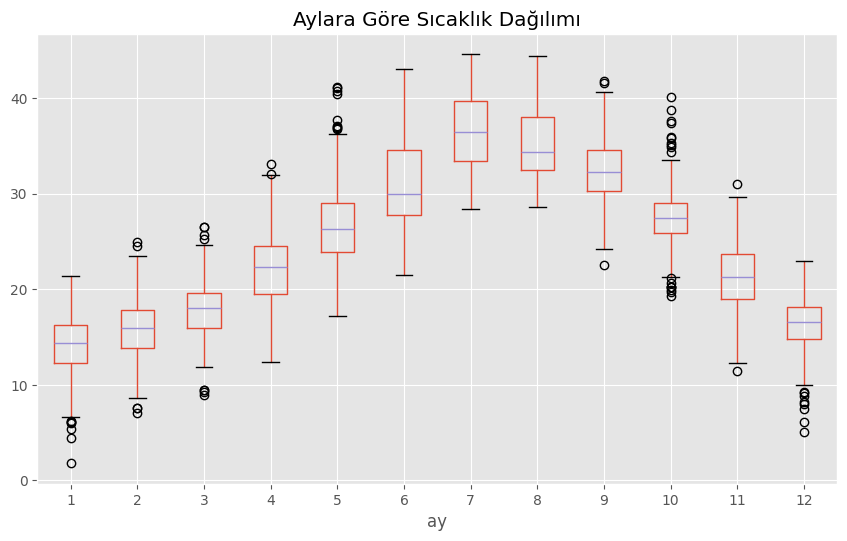

In [7]:
df.boxplot(column='temperature_2m_max', by='ay', figsize=(10,6))
plt.title('Aylara Göre Sıcaklık Dağılımı')
plt.suptitle('') # Üst başlığı temizler
plt.show()

In [ ]:
'''
Varyasyon (Kutularin Boyu): 

Haziran (6. ay) ve Mayis aylarindaki kutularin boyu, Temmuz ve Ağustos'a göre daha uzun. Bu, 
bahar aylarinda sicakliklarin daha istikrarsiz olduğunu (bir gün çok sicak,
bir gün serin olabildiğini) söyler. Yazin (7-8. aylar) ise kutular daralir;
yani hava her gün "istikrarli bir şekilde" çok sicaktir.


Aykiri Değerler (Siyah Halkalar):

Ocak ve Şubat aylarinda altta kalan noktalar,o 10 yil içinde 
yaşanan ekstrem soğuk dalgalarinin veya don olaylarini temsil eder.
Mayis ve Ekim aylarindaki üst noktalar, beklenmedik sicak hava dalgalarini
gösterir. Özellikle Mayis ayinda 40 dereceyi zorlayan ekstrem günler yaşanmiş.

Medyan Hatti (Kutu içindeki mavi çizgi):
Eğer bu çizgi kutunun tam ortasinda değilse,
o aydaki sicaklik dağiliminda bir çarpiklik (skewness) vardir.
'''

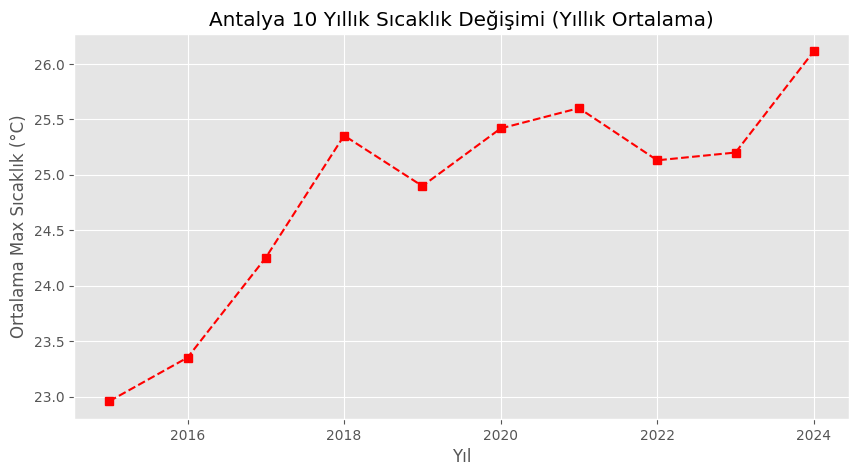

In [8]:
# Her yılın ortalama maksimum sıcaklığını hesapla
yillik_trend = df.groupby('yil')['temperature_2m_max'].mean()

plt.figure(figsize=(10, 5))
yillik_trend.plot(kind='line', marker='s', color='red', linestyle='--')
plt.title('Antalya 10 Yıllık Sıcaklık Değişimi (Yıllık Ortalama)')
plt.xlabel('Yıl')
plt.ylabel('Ortalama Max Sıcaklık (°C)')
plt.grid(True)
plt.show()

Zaman Serisi Analizi:

Pozitif Trend: 2015 yılında ortalama maksimum sıcaklık $23°C$ civarındayken, 2024 yılında bu değer $26°C$ barajını aşmış. 10 yılda ortalama sıcaklıkta yaklaşık $3°C$'lik bir artış gözlemleniyor. Bu, iklim değişikliği çalışmaları için oldukça yüksek ve anlamlı bir artış oranıdır.

Kritik Yıl (2018): 2018'de ani bir yükseliş (basamak atlama) görülüyor. Sonrasındaki yıllarda küçük dalgalanmalar olsa da sıcaklık bir daha asla 2015-2016 seviyelerine düşmemiş. Artık "yeni bir normal" oluşmuş diyebiliriz.

Volatilite (Değişkenlik): Grafikteki zikzaklar (örneğin 2019 ve 2022'deki hafif düşüşler), o yılların daha yağışlı veya serin geçmiş olabileceğini gösterir; ancak genel eğilim (trend hattı) yukarı yönlüdür.


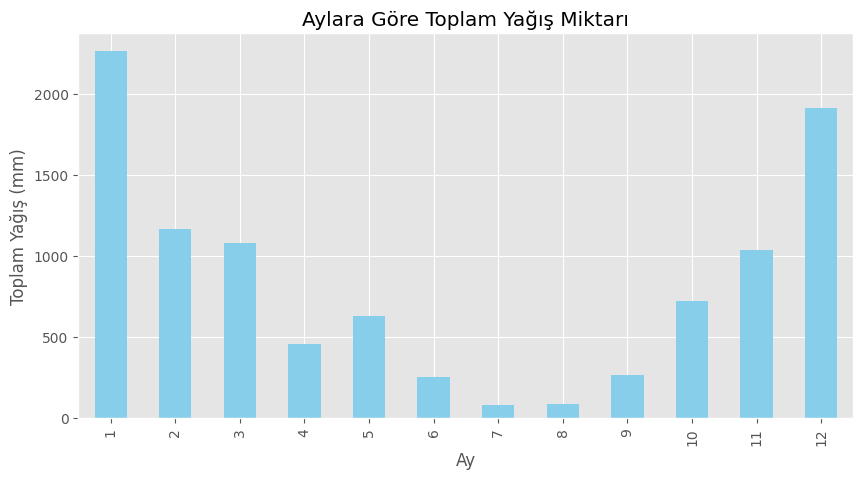

In [9]:
# Aylık toplam yağış
aylik_yagis = df.groupby('ay')['precipitation_sum'].sum()

plt.figure(figsize=(10, 5))
aylik_yagis.plot(kind='bar', color='skyblue')
plt.title('Aylara Göre Toplam Yağış Miktarı')
plt.xlabel('Ay')
plt.ylabel('Toplam Yağış (mm)')
plt.show()

Aylara Göre Toplam Yağış (Mevsimsellik Analizi):

Kış Konsantrasyonu: Yağışların neredeyse tamamı Ocak (1. ay) ve Aralık (12.) aylarında toplanmış. Ocak ayındaki toplam yağış miktarının 2000 mm'yi aşması, Antalya'nın kışın ne kadar ekstrem yağışlar alabildiğini gösteriyor.

Yaz Kuraklığı: 7. ve 8. aylarda (Temmuz-Ağustos) barlar neredeyse görünmez halde. Bu, tarımsal planlama veya su yönetimi projeleri için kritik bir veridir: "Yazın su ihtiyacı maksimumdayken, doğal kaynak (yağış) minimumda.

Asimetrik Yapı: İlkbahar yağışları (Nisan-Mayıs), Sonbahar yağışlarına (Ekim-Kasım) göre daha düşük seyretmiş. Bu da Antalya'da sonbaharın, kışın habercisi olarak daha yağışlı geçtiğini gösterir.

In [10]:
# Örnek: 40 derece üstü gün sayısı
ekstrem_gunler = df[df['temperature_2m_max'] > 40].groupby('yil').size()
print(ekstrem_gunler)

yil
2017     8
2018     8
2019     6
2020    15
2021    18
2022     8
2023    16
2024    22
dtype: int64
